In [ ]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Useful function for plot a 2D dictionary

In [ ]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [ ]:
from numpy._core.fromnumeric import argmin

def OMP(s, D, L, tau, maxiter = 10000):
  M,N = D.shape
  x = np.zeros(N)
  i = 0
  r = s.copy()
  w = []
  while np.linalg.norm(r) > tau and len(w) < L and i < maxiter:

        # Match
        epsilon = np.abs(np.dot(D.T, r))
        jstar = np.argmax(epsilon)

        # Update w
        if jstar not in w:
            w.append(jstar)

        # Least squares update
        D_omega = D[:, w]
        x_omega, _, _, _ = np.linalg.lstsq(D_omega, s, rcond=None)

        #sparse vector and residual
        x = np.zeros(N)
        x[w] = x_omega
        r = s - np.dot(D, x)

        i += 1

  return x

Load the image and rescale it in $[0,1]$

In [ ]:
img = imread(f'{rootfolder}/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [ ]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.randn(*img.shape)

Compute the PSNR of the noisy input

In [ ]:
psnr_noisy = 10 * np.log10(1 / np.mean(np.square(noisy_img - img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

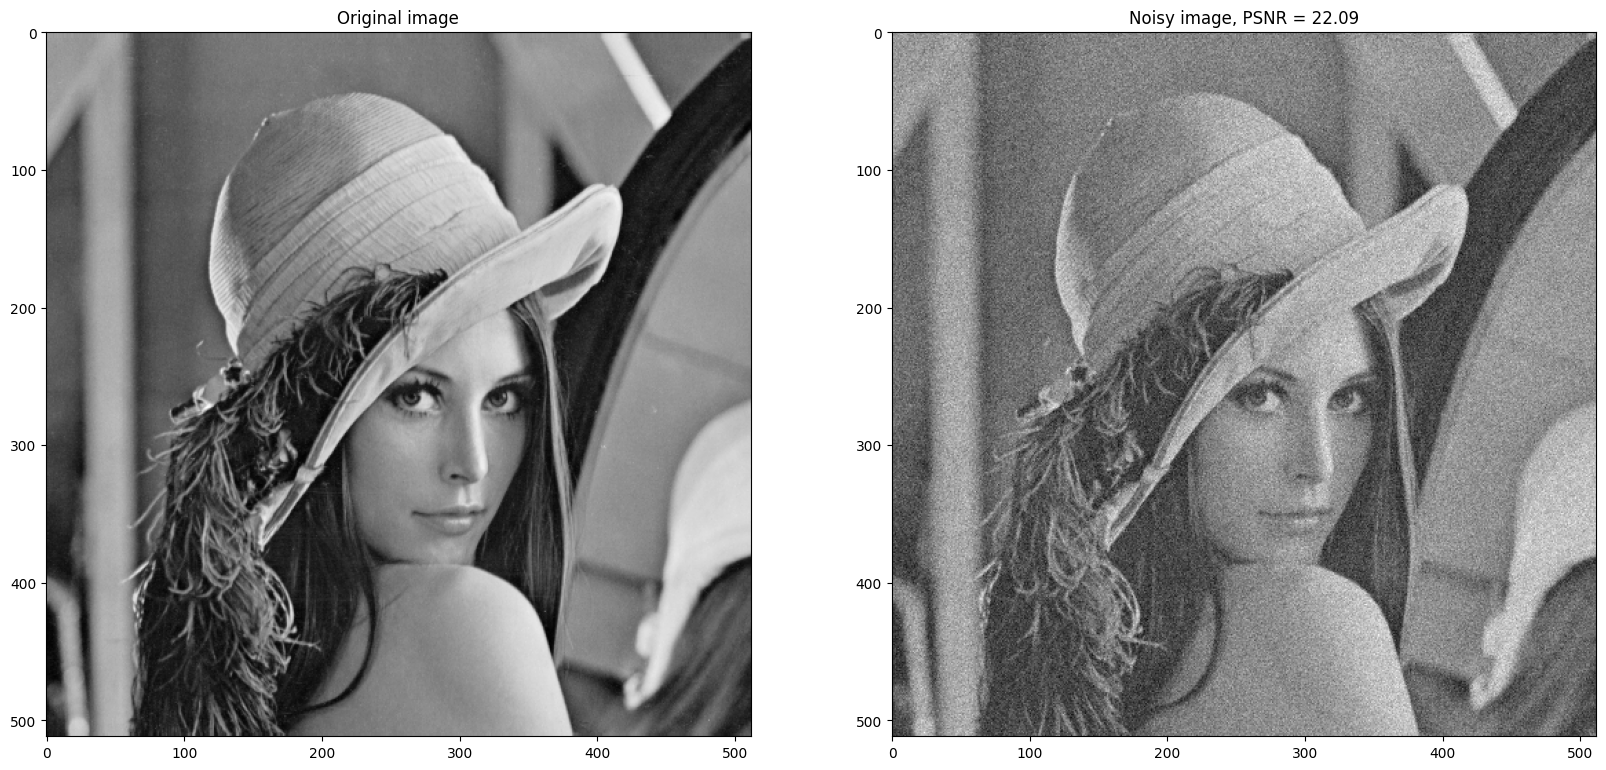

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Load and display the dictionary learned from patches

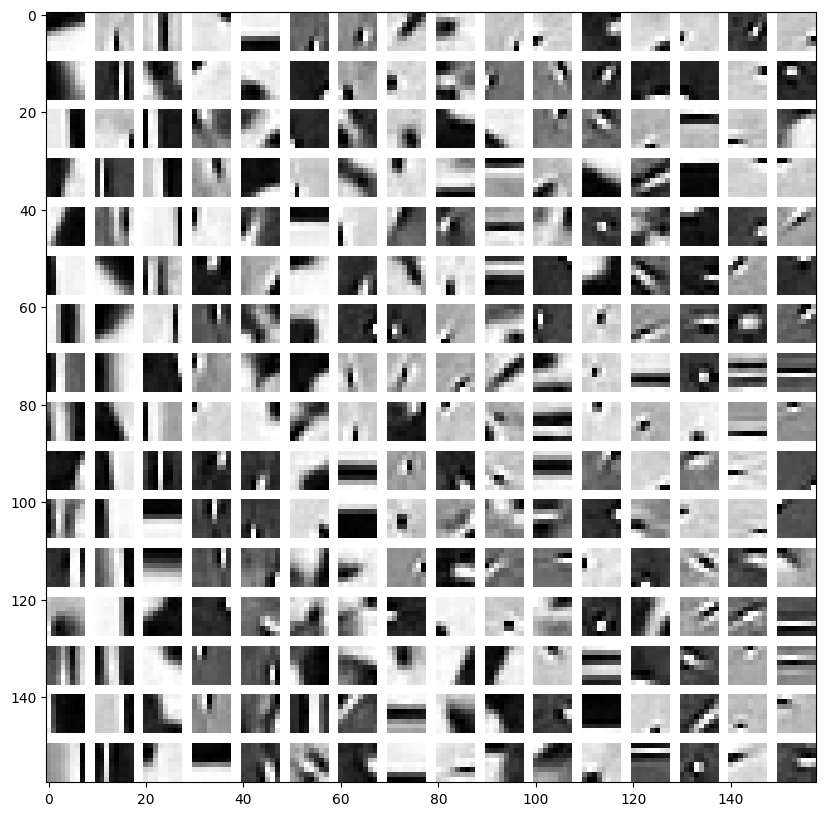

In [ ]:
D = loadmat(f'{rootfolder}/dict_nat_img.mat')['D']

# display the learned basis
D_img = get_dictionary_img(D)
plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')

Denoising
---------


In [ ]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# set the threshold
tau = 1.15 * p * sigma_noise
L = int(M / 2)
# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise

In [ ]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i: i + p, j: j + p].reshape(-1)

        # store and subtract the mean
        s_mean = np.mean(s)
        s = s - s_mean

        # perform the sparse coding
        x = OMP(s, D, L, tau)

        # perform the reconstruction
        s_hat = np.dot(D, x)


        # add back the mean
        s_hat = s_hat + s_mean

        # put the denoised patch into the estimated image using uniform weights
        img_hat[i: i + p, j: j + p] = img_hat[i: i + p, j: j + p] + s_hat.reshape(8,8)

        # store the weight of the current patch in the weight matrix
        weights[i: i + p, j: j + p] = weights[i: i + p, j: j + p] + 1

Normalize the estimated image with the computed weights

In [ ]:
img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 31.01')

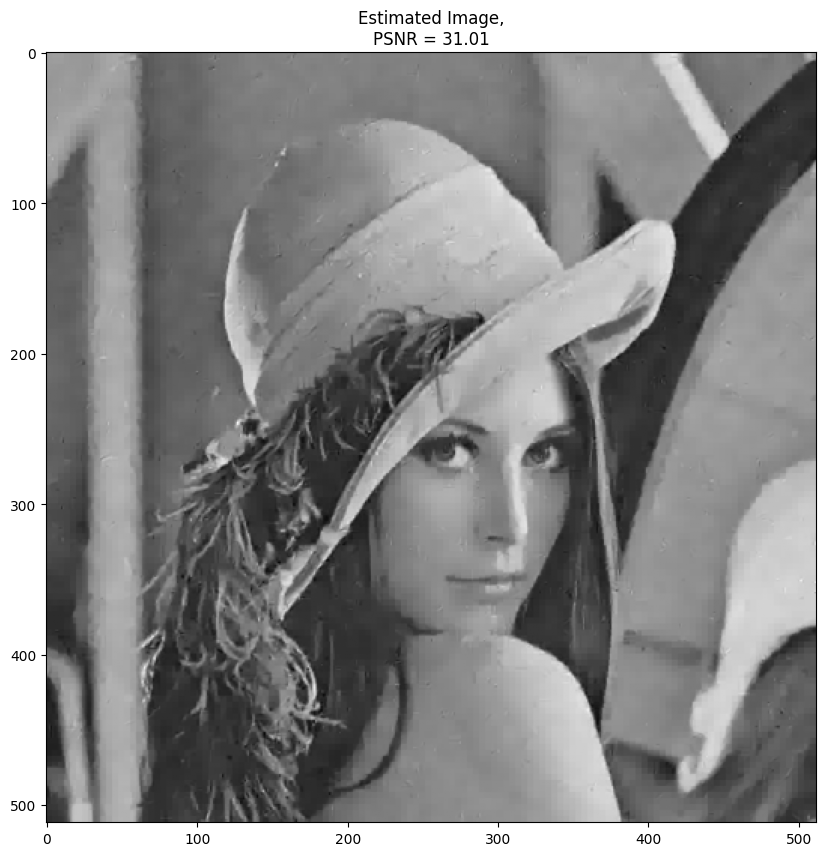

In [ ]:
psnr_hat = 10 * np.log10(1 / np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')


Tikhonov Regularization Denoising
---------
Apply Tikhonov regularization and compare to OMP Denosing

In [ ]:
# initialize the estimated image for Tikhonov
img_hat_tic = np.zeros_like(img)

# initialize the weight matrix
weights_tic = np.zeros_like(img)

# set the regularization parameter
lmbda = 100

# precompute the Tikhonov matrix: x_tic = (D.T * D + lambda * I)^-1 * D.T * s
M, N = D.shape
H_tic = np.dot(D.T, D) + lmbda * np.eye(N)
H_tic = np.linalg.inv(H_tic)
H_tic = np.dot(H_tic, D.T)

In [ ]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extract the patch with the top left corner at pixel (i, j)
        s = noisy_img[i: i + p, j: j + p].reshape(-1)

        # store and subtract the mean
        s_mean = np.mean(s)
        s = s - s_mean

        # solve using Tikhonov closed form
        x_tic = np.dot(H_tic, s)

        # perform the reconstruction
        s_hat = np.dot(D, x_tic)

        w = 1

        # add back the mean
        s_hat = s_hat + s_mean

        # put the denoised patch into the estimated image using uniform weights
        #UPDATE img_hat_tic
        img_hat_tic[i: i + p, j: j + p] = img_hat_tic[i: i + p, j: j + p] + s_hat.reshape(8,8)

        # store the weight of the current patch in the weight matrix
        #UPDATE weights_tic
        weights_tic[i: i + p, j: j + p] = weights_tic[i: i + p, j: j + p] + w

Normalize the estimated image and evaluate the PSNR

Text(0.5, 1.0, 'Estimated Image (Tikhonov),\nPSNR = 26.29')

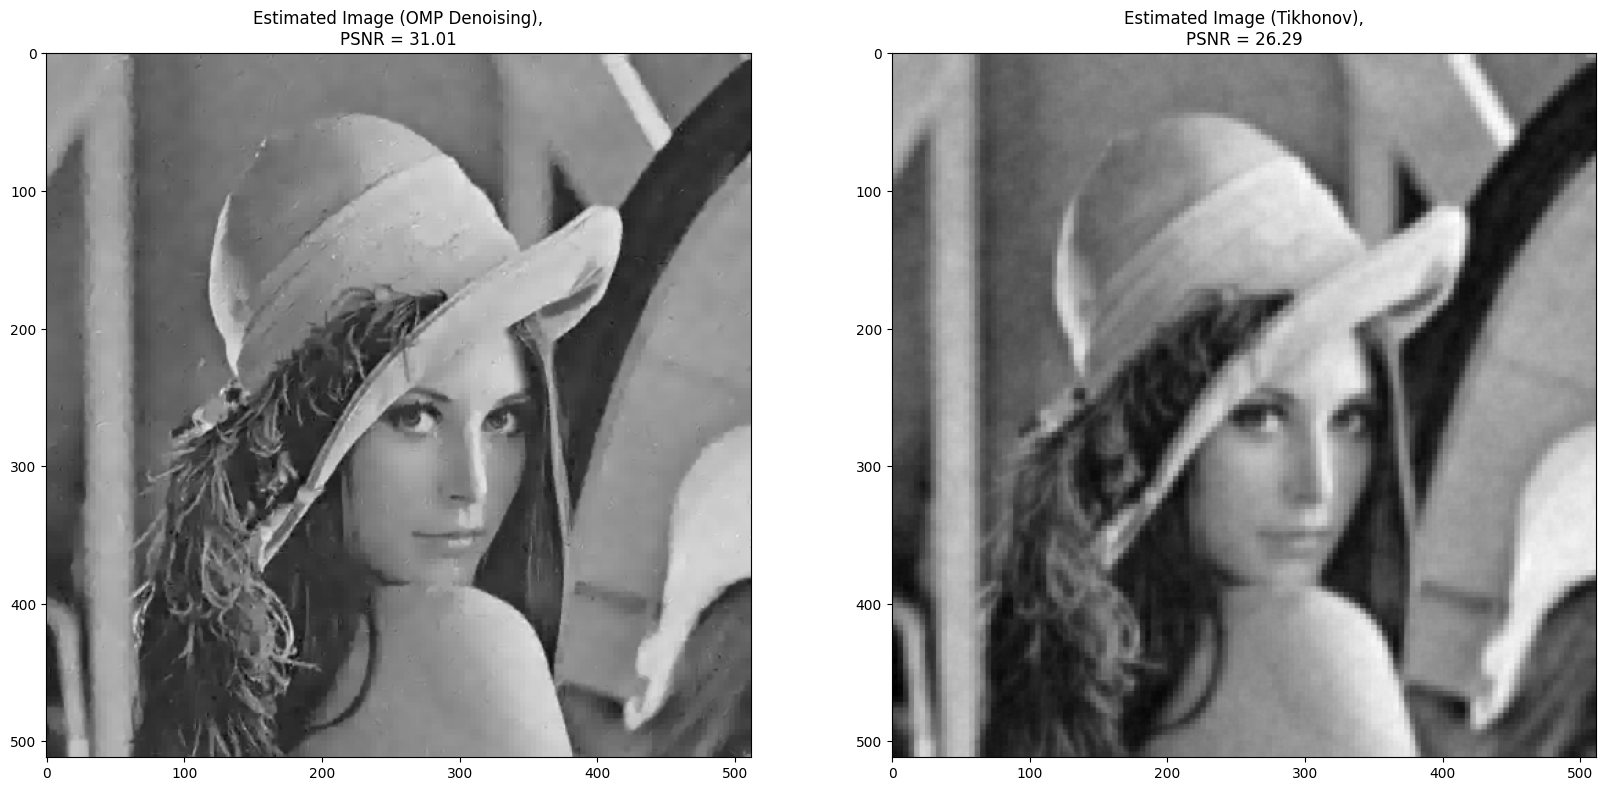

In [ ]:
# normalize the estimated image with the computed weights
img_hat_tic = img_hat_tic / weights_tic

# compute the PSNR of the Tikhonov estimated image
psnr_hat_tic = 10 * np.log10(1 / np.mean(np.square(img_hat_tic - img)))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'Estimated Image (OMP Denoising),\nPSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_tic, cmap='gray')
ax[1].set_title(f'Estimated Image (Tikhonov),\nPSNR = {psnr_hat_tic:.2f}')